In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# PetImages/
# Cat/
cat_path = "/content/cat.jpg1.jpg"
# Dog/
dog_path = "/content/dog.jpg1.jpg"
data = []
labels = []

In [ ]:
base_image_dir = '/content/'

cat_images_to_process = []
dog_images_to_process = []

all_files = os.listdir(base_image_dir)

for filename in all_files:
    if filename.startswith('cat') and filename.endswith('.jpg'):
        cat_images_to_process.append(os.path.join(base_image_dir, filename))
    elif filename.startswith('dog') and filename.endswith('.jpg'):
        dog_images_to_process.append(os.path.join(base_image_dir, filename))

for img_path in cat_images_to_process[:1000]:
    try:
        image = cv2.imread(img_path)
        if image is not None:
            image = cv2.resize(image, (64, 64))
            data.append(image.flatten())
            labels.append(0)
    except Exception:
        pass

for img_path in dog_images_to_process[:1000]:
    try:
        image = cv2.imread(img_path)
        if image is not None:
            image = cv2.resize(image, (64, 64))
            data.append(image.flatten())
            labels.append(1)
    except Exception:
        pass

X = np.array(data)
y = np.array(labels)

print("Dataset Shape:", X.shape)

Dataset Shape: (4, 12288)


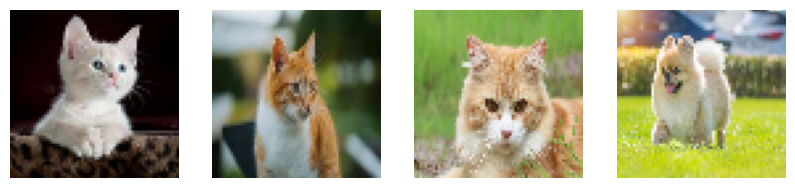

In [ ]:
plt.figure(figsize=(10,5))

num_images_to_display = min(5, X.shape[0])

for i in range(num_images_to_display):
    plt.subplot(1, num_images_to_display, i+1)

    img = X[i].reshape(64,64,3)

    plt.imshow(cv2.cvtColor(img.astype('uint8'),
                            cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
svm = SVC(kernel='linear')

svm.fit(X_train, y_train)

SVC(kernel='linear')

In [ ]:
y_pred = svm.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1



In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [ ]:
image_path = "/content/dog.jpg2.jpg"
image = cv2.imread(image_path)

if image is None:
    print(f"Error: Could not load image from {image_path}. Please ensure the file exists and is accessible.")
else:
    image = cv2.resize(image, (64,64))

    image = image.flatten().reshape(1,-1)

    prediction = svm.predict(image)

    if prediction[0] == 0:
        print("Cat")
    else:
        print("Dog")

Dog
